# Lab 03 — Chunking (sobre los códigos penales)

Un recorrido visual del Lab 03. **Importa los módulos del propio lab**
(`chunkers`, `compare`, `shared.*`) — aquí no se duplica lógica, así que este
notebook y `compare.py` nunca se desincronizan.

El corpus son los dos **códigos** mexicanos (CNPP + Código Penal Federal), donde la
estructura de artículos existe y por tanto la estrategia de chunking *cambia algo*.
La pregunta del lab: *manteniendo fijo el corpus, las preguntas y el embedder,
¿dónde conviene cortar el texto?*

**Antes de correr:** `./tunnel.sh` (Postgres + un embedder TEI **multilingüe**, el
corpus está en español).

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Sube hasta la carpeta que contiene shared/ y agrega este lab al path, para que
# `import chunkers` / `import compare` funcionen sin importar desde dónde se abrió Jupyter.
current_dir = Path.cwd()
labs_folder = next(d for d in [current_dir, *current_dir.parents] if (d / "shared").exists())
for import_dir in (str(labs_folder), str(labs_folder / "03_chunking")):
    if import_dir not in sys.path:
        sys.path.insert(0, import_dir)
print("labs root:", labs_folder)

labs root: /Users/savashito/Claude/Projects/AI_research/RAG/labs


## Parte 1 — El problema: la ventana fija parte el artículo

La unidad natural de recuperación en un código es el **artículo**. El chunker de
ventana fija corta cada N palabras, sin respetar esos límites, así que el
'Artículo N' puede quedar partido entre dos chunks (o mezclado con el vecino). El
chunker **por artículo** lo mantiene entero. Veámoslo con el Artículo 261 del
CNPP (define dato/medio/prueba).

In [2]:
import re
import chunkers

cnpp_text = (labs_folder / "ingestion" / "out" / "Sistema Penal Acusatorio"
             / "Código Nacional de Procedimientos Penales.md").read_text()

def chunks_mentioning_261(chunks):
    return [chunk for chunk in chunks if re.search(r"Art[íi]culo\s+261\b", chunk, re.I)]

fixed_261   = chunks_mentioning_261(chunkers.fixed(cnpp_text, size=150, overlap=25))
article_261 = chunks_mentioning_261(chunkers.by_article(cnpp_text, max_words=250))

print(f"VENTANA FIJA — 'Artículo 261' aparece en {len(fixed_261)} chunk(s); el primero NO empieza en el artículo:")
print("  ", " ".join(fixed_261[0].split())[:300], "...\n")
print("POR ARTÍCULO — 'Artículo 261' es un chunk propio, entero:")
print("  ", " ".join(article_261[0].split())[:300], "...")

VENTANA FIJA — 'Artículo 261' aparece en 1 chunk(s); el primero NO empieza en el artículo:
   serán valoradas aquellas pruebas que hayan sido desahogadas en la audiencia de juicio, salvo las excepciones previstas en este Código. ## **Artículo 260. Antecedente de investigación** El antecedente de investigación es todo registro incorporado en la carpeta de investigación que sirve de sustento p ...

POR ARTÍCULO — 'Artículo 261' es un chunk propio, entero:
   ## **Artículo 261. Datos de prueba, medios de prueba y pruebas** El dato de prueba es la referencia al contenido de un determinado medio de convicción aún no desahogado ante el Órgano jurisdiccional, que se advierta idóneo y pertinente para establecer razonablemente la existencia de un hecho delicti ...


## Parte 2 — ¿De qué tamaño son los artículos? (elegir `max_words` con datos)

`by_article` mantiene cada artículo entero **si cabe** en `max_words`; los más
largos se sub-dividen en ventanas. Así que el tope no debería elegirse a ojo.
Veamos la distribución real de palabras por artículo
(`compare.article_word_counts()`), sus percentiles, y qué fracción cabe entera
bajo distintos topes candidatos.

{'Código Nacional de Procedimientos Penales': [68, 103, 607, 79, 85, 35, 26, 54, 92, 136, 39, 73, 44, 38, 62, 43, 180, 61, 112, 422, 388, 196, 34, 100, 84, 245, 177, 208, 184, 170, 113, 51, 60, 71, 151, 47, 409, 55, 21, 86, 157, 60, 69, 151, 388, 36, 80, 66, 199, 122, 106, 42, 121, 65, 189, 167, 445, 56, 48, 51, 74, 166, 53, 145, 47, 157, 282, 56, 123, 59, 156, 66, 59, 59, 86, 175, 381, 47, 73, 105, 57, 404, 142, 82, 194, 99, 72, 26, 39, 235, 316, 67, 52, 215, 87, 94, 80, 133, 138, 171, 172, 36, 51, 355, 98, 96, 103, 166, 1053, 172, 99, 59, 759, 90, 99, 33, 448, 56, 44, 54, 121, 69, 35, 69, 91, 125, 71, 102, 242, 27, 806, 710, 87, 242, 196, 111, 332, 293, 122, 139, 401, 79, 275, 123, 426, 163, 151, 171, 112, 335, 122, 186, 74, 178, 280, 131, 144, 47, 56, 23, 114, 43, 38, 281, 117, 148, 1455, 203, 107, 92, 84, 135, 203, 415, 88, 111, 517, 80, 52, 79, 115, 67, 115, 25, 53, 49, 214, 113, 218, 179, 81, 213, 44, 39, 351, 131, 60, 316, 102, 74, 179, 312, 173, 37, 134, 135, 37, 61, 73, 132, 2

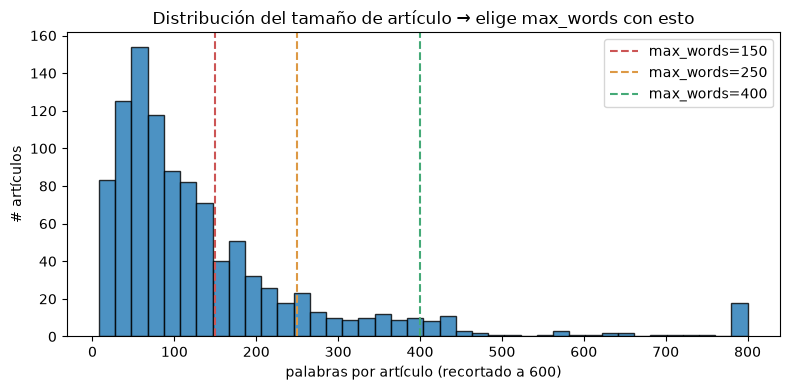

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import compare

counts_by_code = compare.article_word_counts()
print(counts_by_code)
print(f"{'código':<40}{'#art':>6}{'min':>6}{'p50':>6}{'p90':>6}{'p95':>6}{'max':>8}")
for name, counts in counts_by_code.items():
    values = np.array(counts)
    print(f"{name[:38]:<40}{len(values):>6}{values.min():>6}"
          f"{int(np.percentile(values, 50)):>6}{int(np.percentile(values, 90)):>6}"
          f"{int(np.percentile(values, 95)):>6}{values.max():>8}")

all_counts = np.array([count for counts in counts_by_code.values() for count in counts])
print("\n% de artículos que caben ENTEROS en un chunk (el resto se sub-divide):")
for cap in (150, 250, 400, 600, 800):
    fits = (all_counts <= cap).mean() * 100
    print(f"  ≤{cap:>4} palabras: {fits:5.1f}%   (>{cap}: {(all_counts > cap).sum()} artículos)")

# histograma (recortado a 600 palabras para ver el grueso) con los topes candidatos
figure, axis = plt.subplots(figsize=(8, 4))
axis.hist(np.clip(all_counts, 0, 800), bins=40, edgecolor="black", alpha=0.8)
for cap, color in [(150, "#cc5555"), (250, "#dd9944"), (400, "#44aa77")]:
    axis.axvline(cap, color=color, linestyle="--", label=f"max_words={cap}")
axis.set_xlabel("palabras por artículo (recortado a 600)")
axis.set_ylabel("# artículos")
axis.set_title("Distribución del tamaño de artículo → elige max_words con esto")
axis.legend()
plt.tight_layout()
plt.show()

In [23]:
def article_word_counts() -> dict[str, list[tuple[str, int]]]:
    return {
        name: sorted([
            (span, len(span.split()))
            for span in chunkers.article_spans(text)
        ], key=lambda x: x[1])
        for name, text in compare.load_docs()
    }
articulos = article_word_counts()
cap = 1000
# print(f"  ≤{cap:>4} palabras: {fits:5.1f}%   (>{cap}: {(all_counts > cap).sum()} artículos)")
print(articulos['Código Nacional de Procedimientos Penales'][-1][0])
# print(articulos['Código Nacional de Procedimientos Penales'][-2][1])
# print(articulos['Código Nacional de Procedimientos Penales'][-3][1])


artículo 22 de la Constitución Política de los Estados Unidos Mexicanos; y se reforma y adiciona la Ley de Amparo, Reglamentaria de los artículos 103 y 107 de la Constitución Política de los Estados Unidos Mexicanos, publicado en el Diario Oficial de la Federación el veintinueve de mayo de dos mil nueve, serán transferidos a la cuenta especial. 

**Sexto.** El presente Decreto será aplicable para los procedimientos de preparación de la acción de extinción de dominio que se inicien a partir de su entrada en vigor, con independencia de que los supuestos para su procedencia hayan sucedido con anterioridad, siempre y cuando no se haya ejercido la acción de extinción de dominio. 

**Séptimo.** Todas las referencias que hagan mención al Servicio de Administración y Enajenación de Bienes en la normatividad vigente, se entenderán realizadas al Instituto para Devolver al Pueblo lo Robado, por lo que las obligaciones a cargo de dicho organismo que se generen con la entrada en vigor del presente

## Parte 3 — Chunkear con cada estrategia y medir

`compare.build()` chunkea el corpus con cada estrategia, embebe y guarda todos los
chunks en una tabla (con columna `strategy`). `compare.collect_metrics()` devuelve
el `art_hit@k` / MRR: para cada pregunta, ¿algún chunk recuperado contiene el
'Artículo N' esperado? Cambia el embedder a `"tei"` para correr en la RTX 5090.

In [ ]:
from shared.embedder import get_embedder
import compare

embedder = get_embedder("tei")   # multilingüe (Qwen3) — obligatorio para español
n_chunks = compare.build(embedder)
results = compare.collect_metrics(embedder)

print(f"{'strategy':<14}{'#chunks':>8}{'avg_words':>10}{'art@1':>8}{'art@3':>8}{'art@5':>8}{'MRR':>7}")
for result in results:
    print(f"{result['strategy']:<14}{result['n_chunks']:>8}{result['avg_words']:>10.1f}"
          f"{result['art_hit@1']:>8.2f}{result['art_hit@3']:>8.2f}"
          f"{result['art_hit@5']:>8.2f}{result['mrr']:>7.2f}")

## Parte 4 — Visualizar

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

strategy_names = [result["strategy"] for result in results]
x_positions = np.arange(len(strategy_names))
bar_width = 0.25

figure, axis = plt.subplots(figsize=(9, 4))
for offset, metric in enumerate(["art_hit@1", "art_hit@3", "art_hit@5"]):
    axis.bar(x_positions + (offset - 1) * bar_width,
             [result[metric] for result in results], bar_width, label=metric)
axis.set_xticks(x_positions)
axis.set_xticklabels(strategy_names, rotation=30, ha="right")
axis.set_ylim(0, 1.05)
axis.set_ylabel("art_hit@k")
axis.set_title("Estrategia de chunking vs. ¿se recupera el artículo correcto?")
axis.legend()
axis.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Vista de eficiencia: MRR contra cuántas palabras guarda cada chunk en promedio.
# Arriba-y-a-la-izquierda es mejor: buena calidad, menos tokens por chunk.
figure, axis = plt.subplots(figsize=(7, 4))
for result in results:
    axis.scatter(result["avg_words"], result["mrr"])
    axis.annotate(result["strategy"], (result["avg_words"], result["mrr"]),
                  textcoords="offset points", xytext=(6, 4), fontsize=8)
axis.set_xlabel("palabras por chunk (promedio)")
axis.set_ylabel("MRR")
axis.set_title("Calidad vs. tamaño de chunk")
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Pruébalo tú
- Cambia `max_words` de `by-article` en `compare.strategies()` (150 / 250 / 400) y
  re-corre — ¿dónde está el punto dulce?
- Agrega un chunker **semántico en español** (adapta `chunkers.semantic` con
  segmentación `pysbd language="es"`) y compáralo.
- Todo aquí llama al mismo código que `compare.py`, así que lo que aprendas
  transfiere directo al lab de CLI.